In [ ]:
# Setup
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'kaleido==0.2.1', '-q'])

import pandas as pd
import numpy as np
import plotly.io as pio


In [ ]:
df=pd.read_csv('diabetes.csv')

## 1. Exploratory Data Analysis

In [ ]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.shape

(768, 9)

In [ ]:
cols_with_zeros=['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zeros]=df[cols_with_zeros].replace(0, np.nan)


In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,763.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.535641,12.382158,10.476982,118.775855,6.924988,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 2. Missing Value Imputation

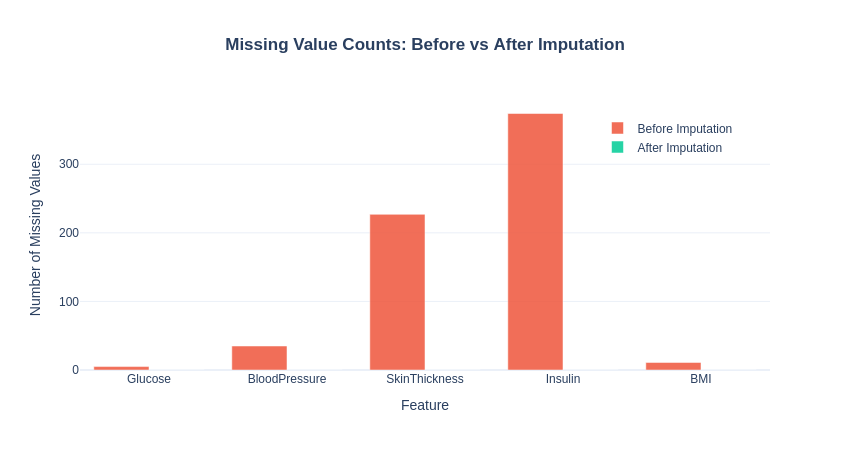

In [ ]:
import plotly.graph_objects as go

pio.renderers.default="png"

cols_with_zeros=['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
raw=pd.read_csv('diabetes.csv')
raw[cols_with_zeros]=raw[cols_with_zeros].replace(0, float('nan'))

before_counts=raw[cols_with_zeros].isnull().sum()
after_counts=[0] * len(cols_with_zeros)

fig_mv=go.Figure(data=[
    go.Bar(name='Before Imputation', x=cols_with_zeros, y=before_counts,
           marker_color='#EF553B', opacity=0.85),
    go.Bar(name='After Imputation',  x=cols_with_zeros, y=after_counts,
           marker_color='#00CC96', opacity=0.85)
])
fig_mv.update_layout(
    barmode='group',
    title='<b>Missing Value Counts: Before vs After Imputation</b>',
    title_x=0.5,
    xaxis_title='Feature',
    yaxis_title='Number of Missing Values',
    template='plotly_white',
    width=850, height=450,
    legend=dict(x=0.75, y=0.95)
)
fig_mv.show()
fig_mv.write_image("missing_values.png")


## 3. Class Distribution & Feature Distributions

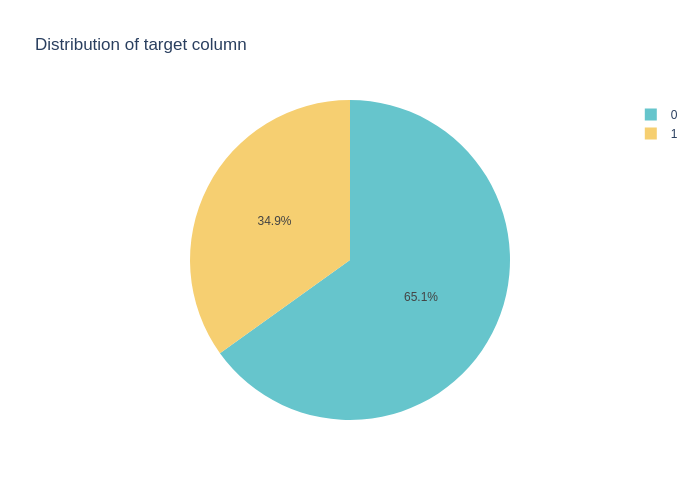

In [ ]:
import plotly.express as px
import plotly.graph_objects as go

pio.renderers.default="png"

fig_balance=px.pie(df, names='Outcome', title='Distribution of target column',
             color_discrete_sequence=px.colors.qualitative.Pastel)
fig_balance.show()
fig_balance.write_image("class_imbalance.png")


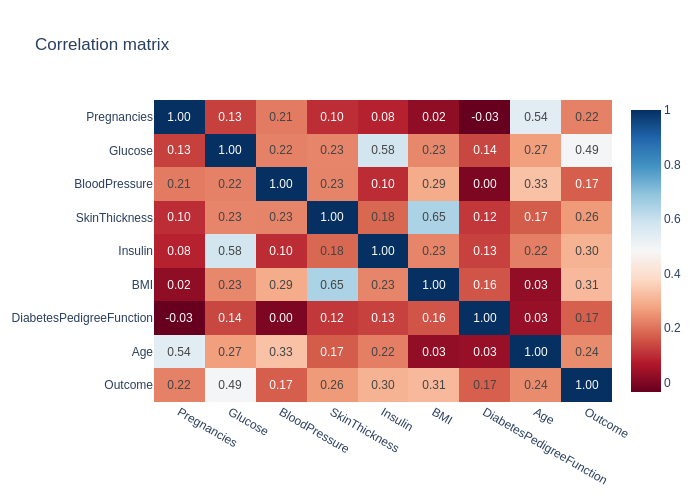

In [ ]:
pio.renderers.default="png"

corr=df.corr()
fig_corr=px.imshow(corr, text_auto='.2f', aspect="auto",
                title="Correlation matrix",
                color_continuous_scale='RdBu')
fig_corr.show()

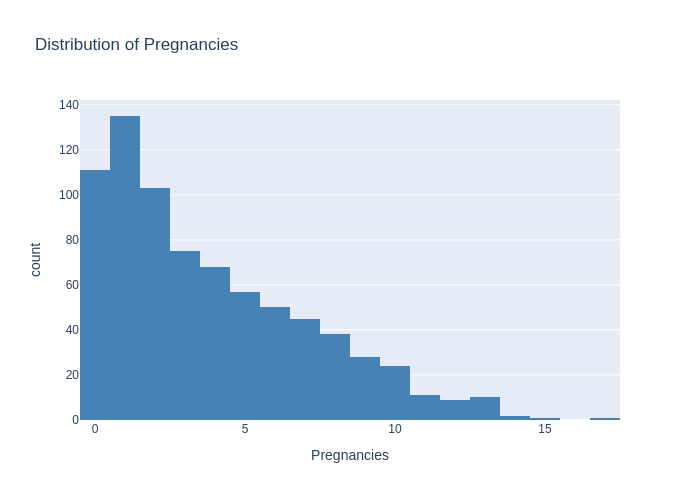

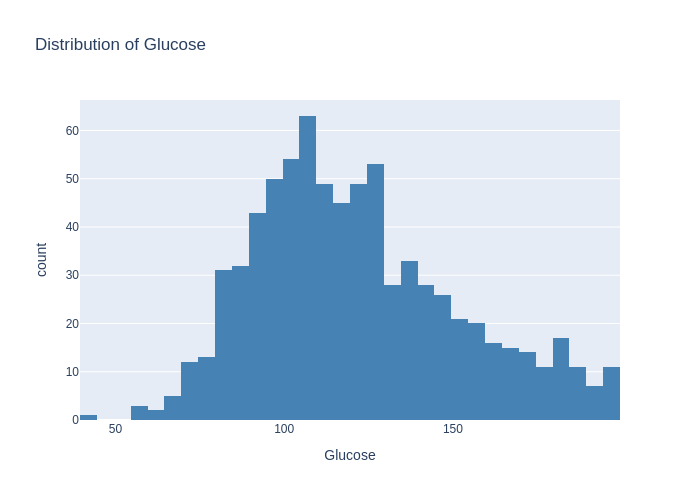

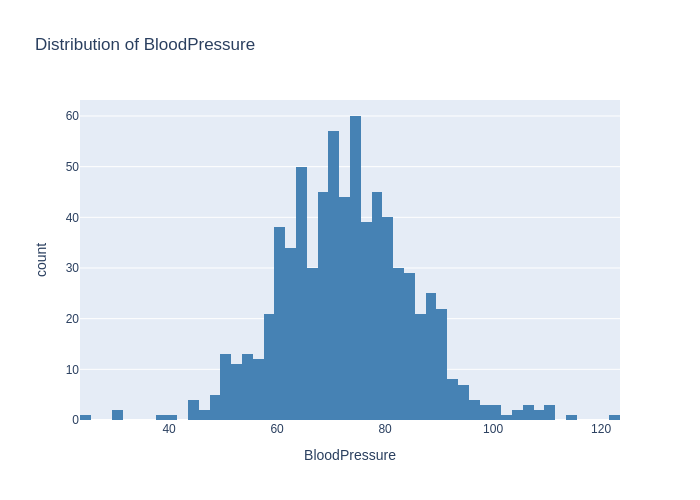

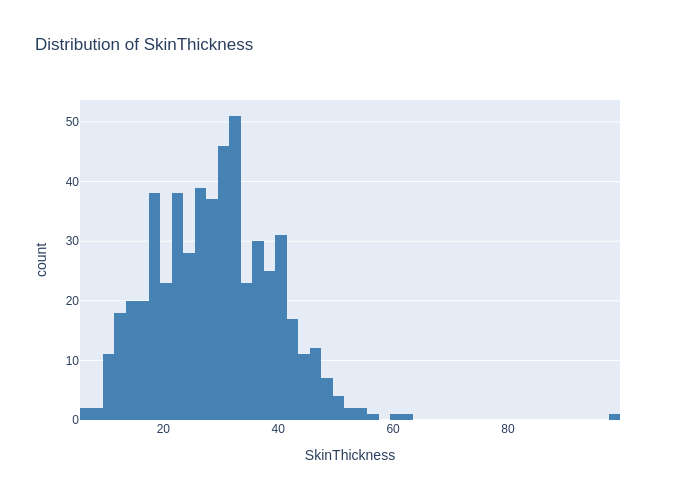

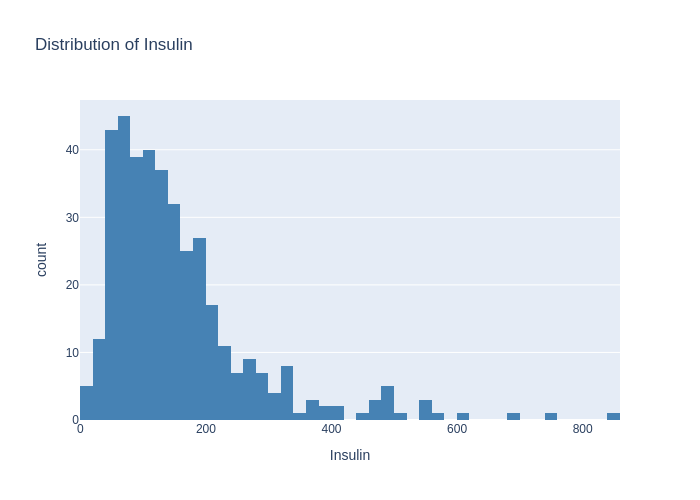

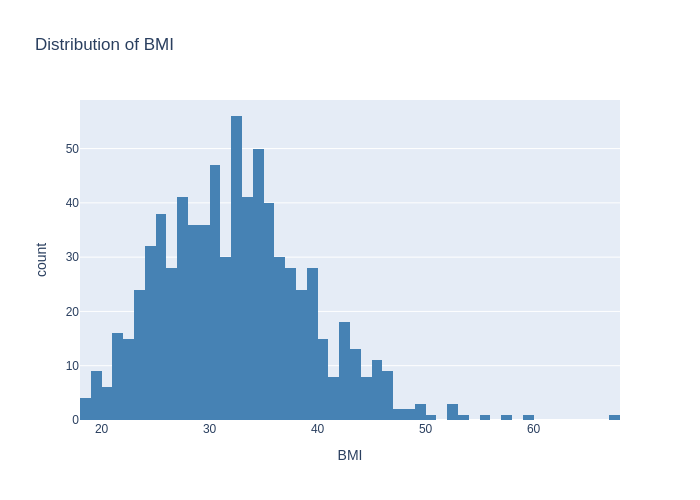

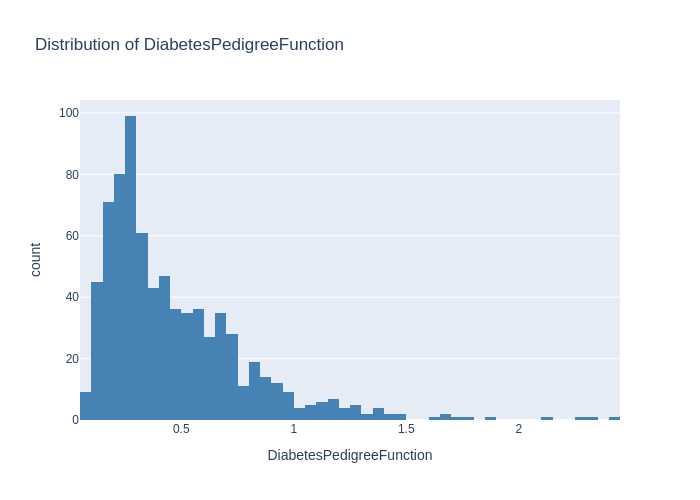

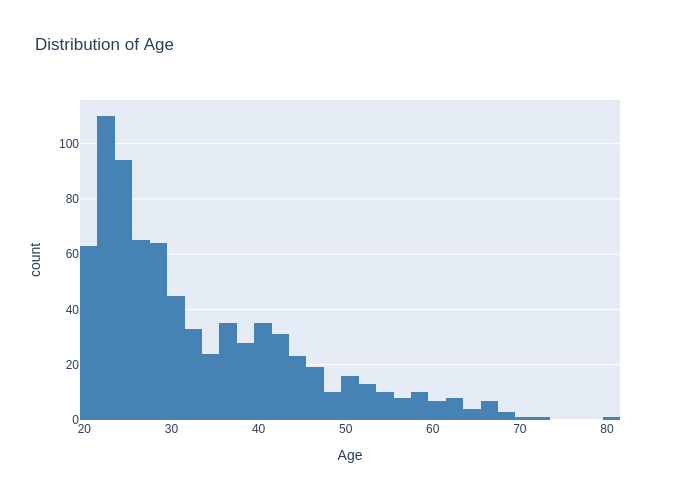

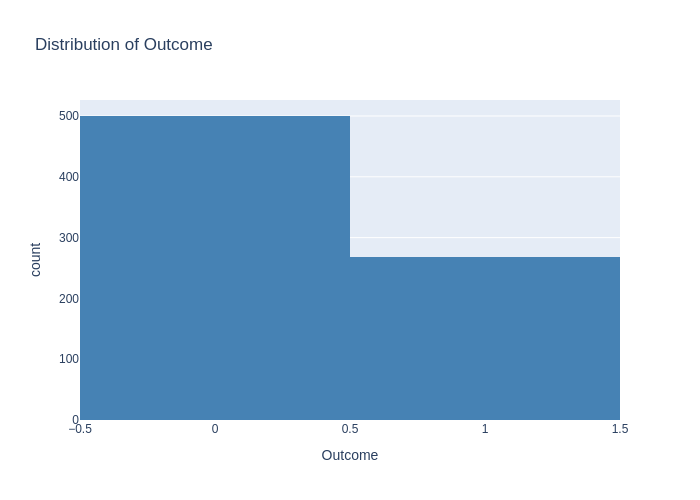

In [ ]:
pio.renderers.default="png"

num_cols=df.select_dtypes(include=np.number).columns.tolist()

for col in num_cols:
    fig=px.histogram(df, x=col, title=f'Distribution of {col}',
                       color_discrete_sequence=['steelblue'])
    fig.show()

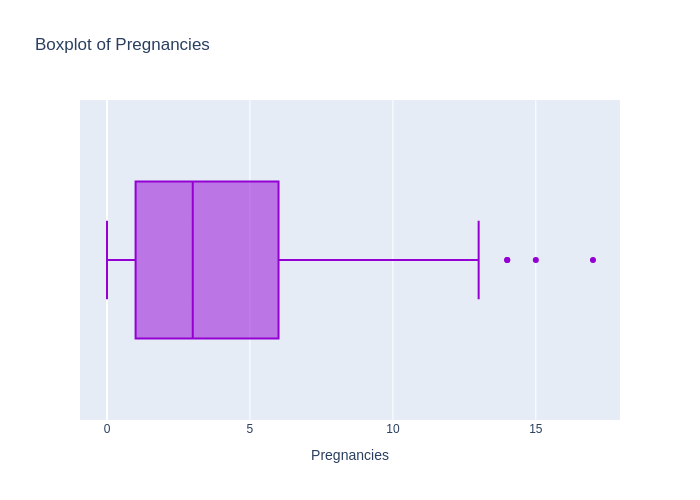

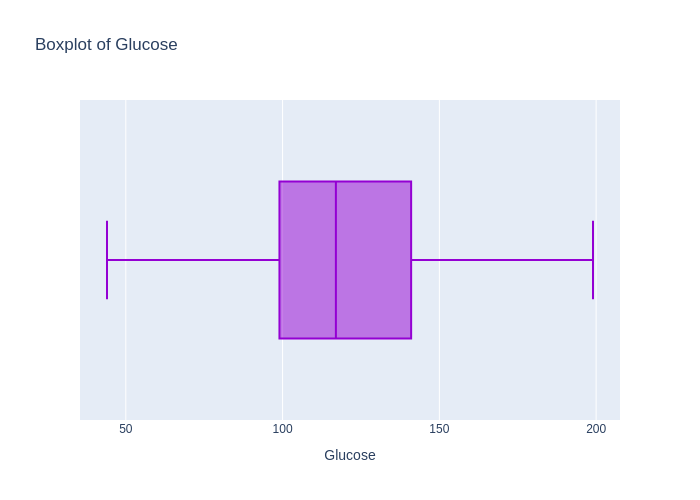

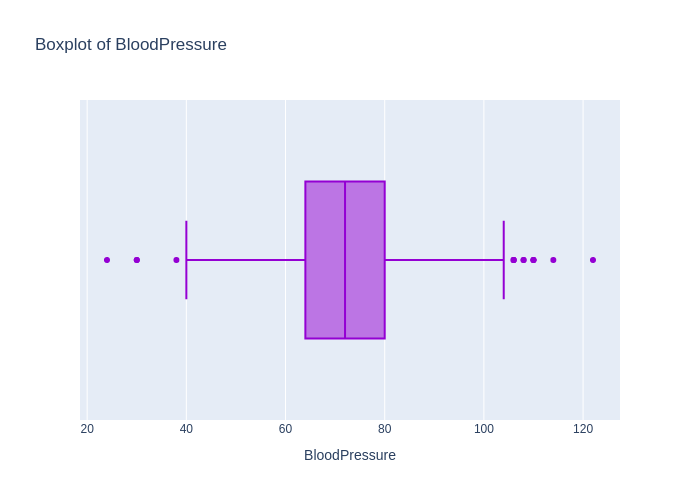

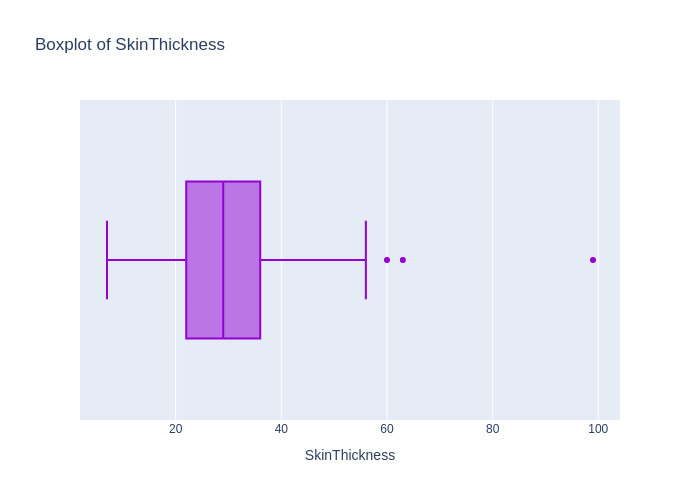

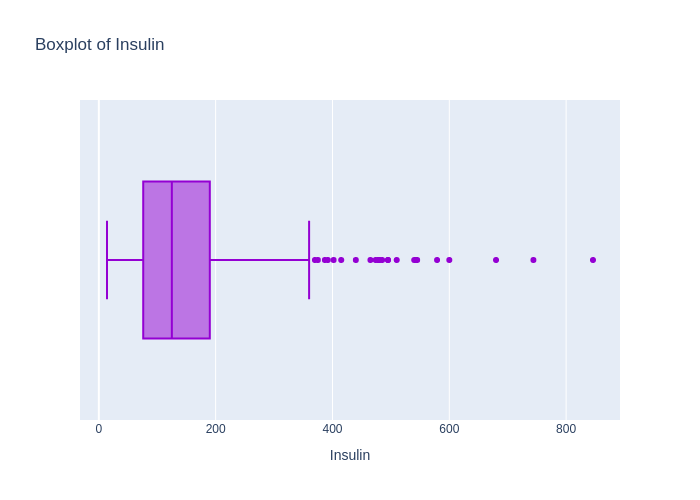

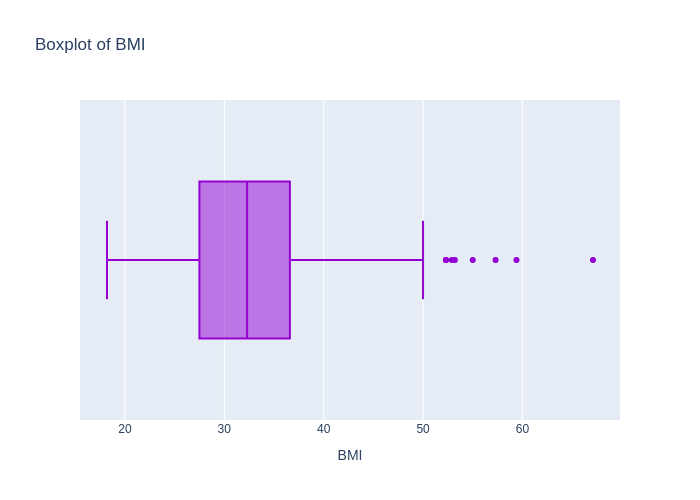

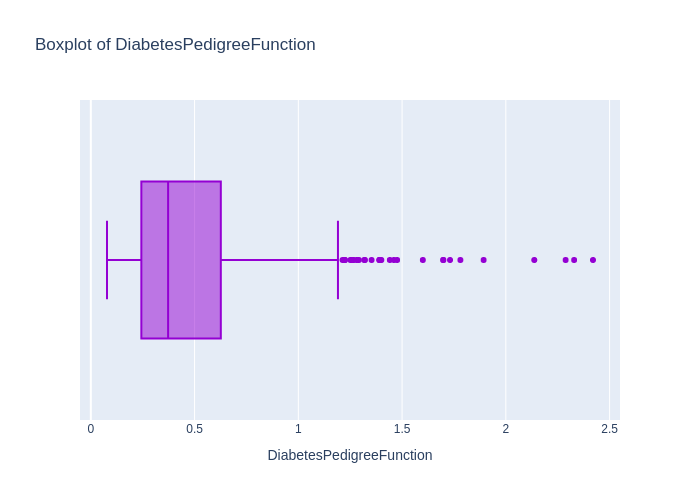

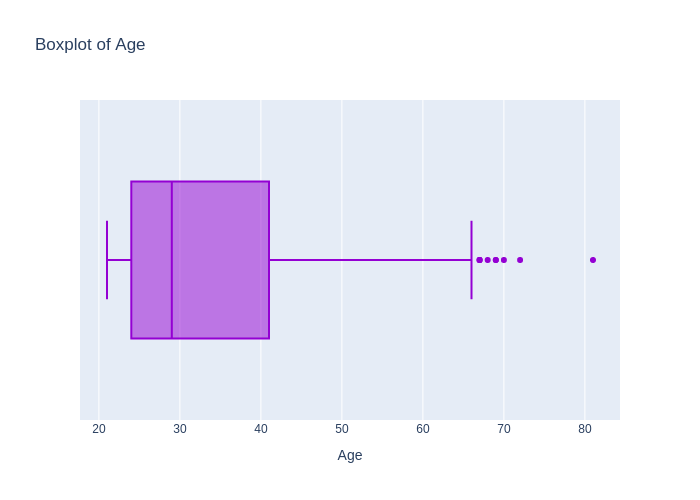

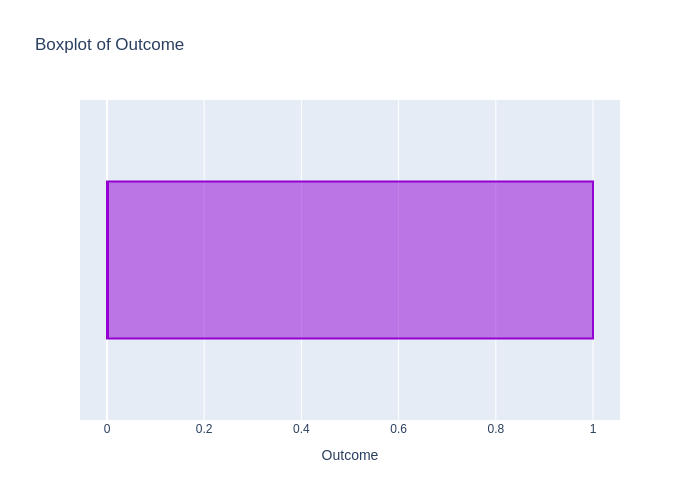

In [ ]:
pio.renderers.default="png"

for col in num_cols:
    fig=px.box(df, x=col, title=f'Boxplot of {col}',
                 color_discrete_sequence=['darkviolet'])
    fig.show()


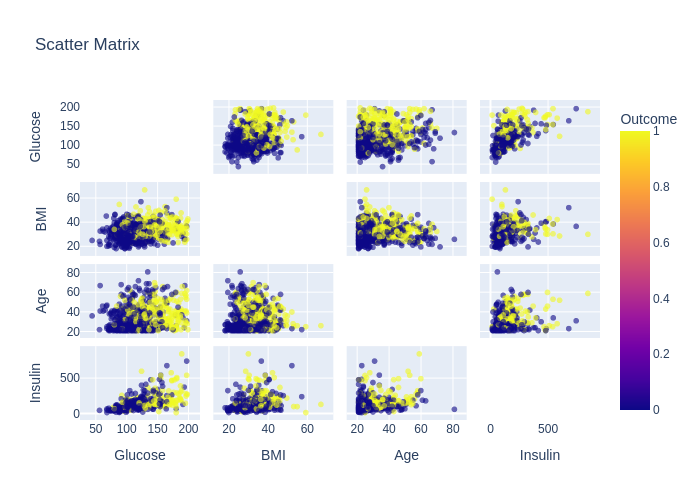

In [ ]:
pio.renderers.default="png"

fig_scatter = px.scatter_matrix(df,
    dimensions=["Glucose", "BMI", "Age", "Insulin"],
    color="Outcome",
    title="Scatter Matrix",
    labels={col: col for col in df.columns},
    opacity=0.6)

fig_scatter.update_traces(diagonal_visible=False)
fig_scatter.show()

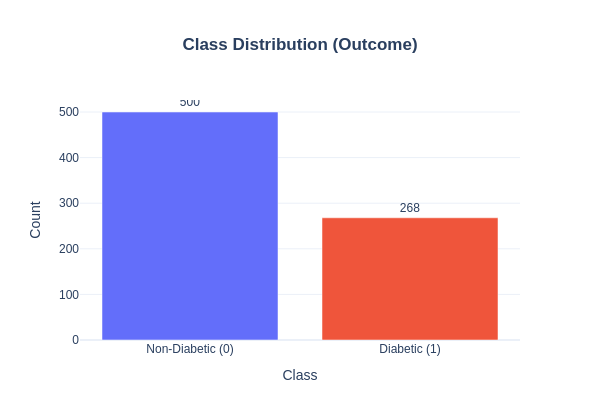

In [ ]:
import plotly.express as px

pio.renderers.default="png"

class_counts=df['Outcome'].value_counts().reset_index()
class_counts.columns=['Outcome', 'Count']
class_counts['Label']=class_counts['Outcome'].map({0: 'Non-Diabetic (0)', 1: 'Diabetic (1)'})

fig_bar=px.bar(class_counts, x='Label', y='Count',
                 color='Label',
                 color_discrete_sequence=['#636EFA', '#EF553B'],
                 text='Count',
                 title='<b>Class Distribution (Outcome)</b>')
fig_bar.update_traces(textposition='outside')
fig_bar.update_layout(
    title_x=0.5, template='plotly_white',
    showlegend=False, width=600, height=420,
    xaxis_title='Class', yaxis_title='Count'
)
fig_bar.show()
fig_bar.write_image("class_distribution.png")


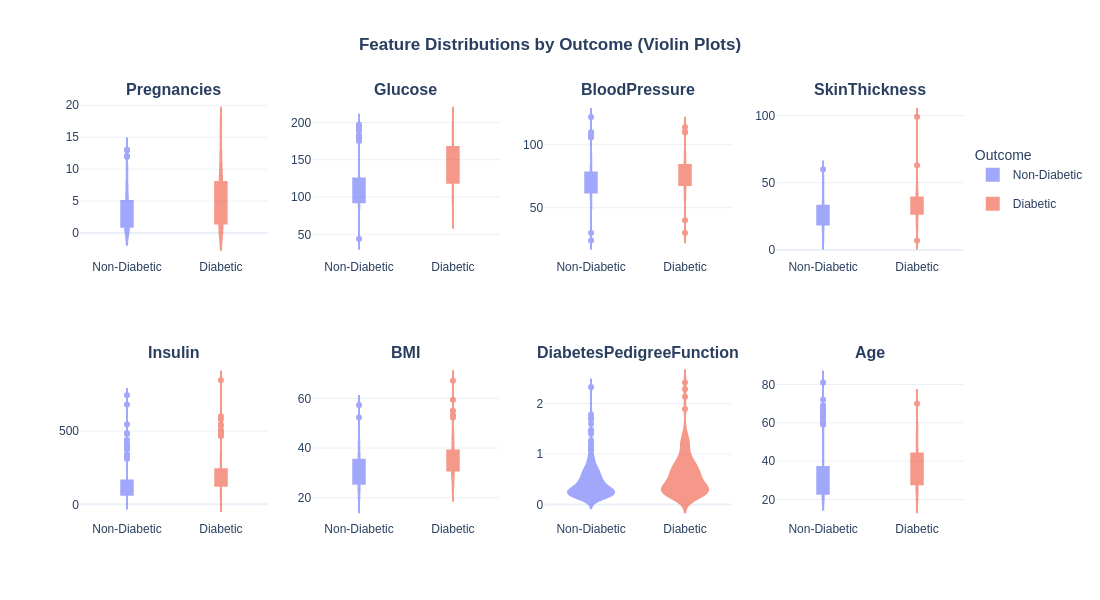

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pio.renderers.default="png"

feature_cols=[c for c in df.columns if c != 'Outcome']
n_cols=4
n_rows=-(-len(feature_cols) // n_cols)

fig_vln=make_subplots(rows=n_rows, cols=n_cols,
                         subplot_titles=[f'<b>{c}</b>' for c in feature_cols])

colors={0: '#636EFA', 1: '#EF553B'}
labels={0: 'Non-Diabetic', 1: 'Diabetic'}

for idx, col in enumerate(feature_cols):
    r = idx // n_cols + 1
    c = idx % n_cols + 1
    for outcome in [0, 1]:
        subset = df[df['Outcome'] == outcome][col]
        fig_vln.add_trace(
            go.Violin(y=subset, name=labels[outcome],
                      legendgroup=str(outcome),
                      showlegend=(idx == 0),
                      line_color=colors[outcome],
                      fillcolor=colors[outcome],
                      opacity=0.6,
                      box_visible=True,
                      meanline_visible=True),
            row=r, col=c
        )

fig_vln.update_layout(
    title_text='<b>Feature Distributions by Outcome (Violin Plots)</b>',
    title_x=0.5, template='plotly_white',
    height=300 * n_rows, width=1100,
    violinmode='overlay',
    legend=dict(title='Outcome', x=1.01, y=0.9)
)
fig_vln.show()


## 4. Normalization – Visual Comparison

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning:

n_quantiles (1000) is greater than the total number of samples (768). n_quantiles is set to n_samples.



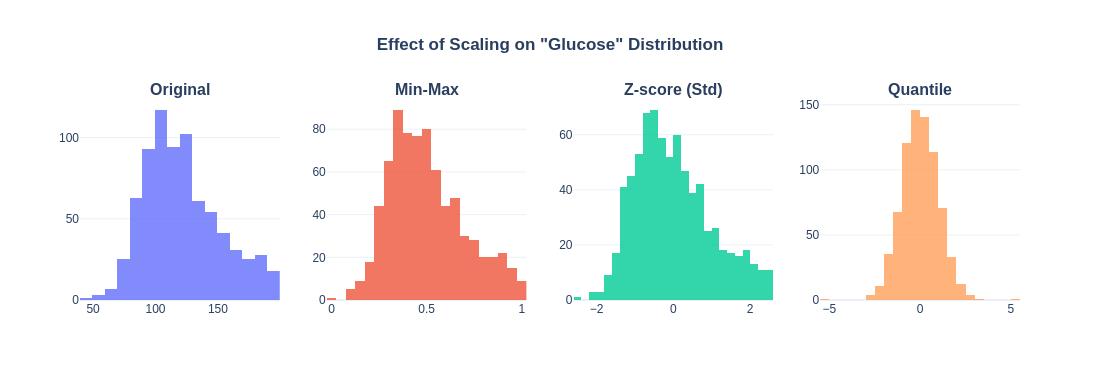

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import MinMaxScaler, StandardScaler, QuantileTransformer
import numpy as np

pio.renderers.default="png"

feature='Glucose'
X_raw=df[[feature]].values

scalers={
    'Original': None,
    'Min-Max': MinMaxScaler(),
    'Z-score (Std)': StandardScaler(),
    'Quantile': QuantileTransformer(output_distribution='normal', random_state=42)
}

fig_scale = make_subplots(rows=1, cols=4,
    subplot_titles=[f'<b>{k}</b>' for k in scalers])

colors = ['#636EFA', '#EF553B', '#00CC96', '#FFA15A']

for i, (name, scaler) in enumerate(scalers.items()):
    if scaler is None:
        vals = X_raw.flatten()
    else:
        vals = scaler.fit_transform(X_raw).flatten()

    fig_scale.add_trace(
        go.Histogram(x=vals, nbinsx=30,
                     marker_color=colors[i], opacity=0.8,
                     name=name, showlegend=False),
        row=1, col=i+1
    )

fig_scale.update_layout(
    title_text=f'<b>Effect of Scaling on "{feature}" Distribution</b>',
    title_x=0.5, template='plotly_white',
    height=380, width=1100,
    margin=dict(t=100)
)
fig_scale.show()
fig_scale.write_image("effect_scaling.png")


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

glucose_mean = X_train['Glucose'].mean()
medians = X_train[['BMI', 'BloodPressure', 'SkinThickness', 'Insulin']].median()

for split in [X_train, X_test]:
    split['Glucose']       = split['Glucose'].fillna(glucose_mean)
    split['BMI']           = split['BMI'].fillna(medians['BMI'])
    split['BloodPressure'] = split['BloodPressure'].fillna(medians['BloodPressure'])
    split['SkinThickness'] = split['SkinThickness'].fillna(medians['SkinThickness'])
    split['Insulin']       = split['Insulin'].fillna(medians['Insulin'])

print('Missing values in X_train after imputation:', X_train.isnull().sum().sum())
print('Missing values in X_test  after imputation:', X_test.isnull().sum().sum())

def get_models():
    return {
        'Logistic Regression': LogisticRegression(max_iter=1000),
        'Random Forest':       RandomForestClassifier(random_state=42),
        'KNN':                 KNeighborsClassifier(),
        'SVM':                 SVC(probability=True, random_state=42),
        'Decision Tree':       DecisionTreeClassifier(random_state=42),
        'XGBoost':             XGBClassifier(eval_metric='logloss', random_state=42)
    }

models = get_models()
baseline_results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    baseline_results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1 Score':  f1_score(y_test, y_pred),
        'ROC AUC':   roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(baseline_results).sort_values(by='F1 Score', ascending=False)
print('Baseline Results (Correct Imputation / No Scaling / No Tuning):')
display(results_df.round(3))

baseline_models = {name: model for name, model in models.items()}


Missing values in X_train after imputation: 0
Missing values in X_test  after imputation: 0
Baseline Results (Correct Imputation / No Scaling / No Tuning):


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
5,XGBoost,0.766,0.688,0.611,0.647,0.816
1,Random Forest,0.766,0.696,0.593,0.640,0.821
0,Logistic Regression,0.701,0.587,0.500,0.540,0.813
3,SVM,0.721,0.649,0.444,0.527,0.781
2,KNN,0.682,0.551,0.500,0.524,0.702
4,Decision Tree,0.675,0.543,0.463,0.500,0.626


In [ ]:
from imblearn.over_sampling import SMOTE

print("Class distribution BEFORE SMOTE:")
print(y_train.value_counts().to_string())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nClass distribution AFTER SMOTE:")
import pandas as pd
print(pd.Series(y_train_smote).value_counts().to_string())
print(f"\nTrain size before: {len(X_train)} → after: {len(X_train_smote)}")


Class distribution BEFORE SMOTE:
Outcome
0    400
1    214

Class distribution AFTER SMOTE:
Outcome
0    400
1    400

Train size before: 614 → after: 800


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

param_grids = {
    "Logistic Regression": {
        "clf__C": np.logspace(-4, 4, 20),
        "clf__penalty": ["l2"],
        "clf__solver": ["lbfgs", "liblinear", "saga"],
        "clf__max_iter": [500, 1000, 2000]
    },
    "Random Forest": {
        "clf__n_estimators": [50, 100, 200, 300, 500],
        "clf__max_depth": [None, 5, 10, 15, 20, 30],
        "clf__min_samples_split": [2, 5, 10, 15],
        "clf__min_samples_leaf": [1, 2, 4],
        "clf__max_features": ["sqrt", "log2", None]
    },
    "KNN": {
        "clf__n_neighbors": list(range(3, 31)),
        "clf__weights": ["uniform", "distance"],
        "clf__metric": ["euclidean", "manhattan", "minkowski"],
        "clf__p": [1, 2]
    },
    "SVM": {
        "clf__C": [0.01, 0.1, 0.5, 1, 5, 10, 50, 100],
        "clf__gamma": ["scale", "auto", 0.001, 0.01, 0.1],
        "clf__kernel": ["rbf", "linear", "poly", "sigmoid"]
    },
    "Decision Tree": {
        "clf__max_depth": [None, 3, 5, 7, 10, 15, 20],
        "clf__min_samples_split": [2, 5, 10, 20, 30],
        "clf__min_samples_leaf": [1, 2, 4, 8],
        "clf__criterion": ["gini", "entropy"]
    },
    "XGBoost": {
        "clf__n_estimators": [50, 100, 200, 300],
        "clf__learning_rate": [0.01, 0.05, 0.1, 0.2, 0.3],
        "clf__max_depth": [3, 4, 5, 6, 7, 8],
        "clf__subsample": [0.6, 0.8, 1.0],
        "clf__colsample_bytree": [0.6, 0.8, 1.0]
    }
}

models = get_models()

tuned_results=[]
best_models_minmax={}

for name, model in models.items():
    print(f"Searching...: {name}...")

    pipe=Pipeline([
        ('scaler', MinMaxScaler()),
        ('clf', model)
    ])

    rs=RandomizedSearchCV(
        pipe,
        param_distributions=param_grids[name],
        n_iter=30,
        cv=5,
        scoring='roc_auc',
        random_state=42,
        n_jobs=-1
    )

    rs.fit(X_train_smote, y_train_smote)

    best_pipe=rs.best_estimator_
    best_models_minmax[name]=best_pipe

    y_pred=best_pipe.predict(X_test)
    y_prob=best_pipe.predict_proba(X_test)[:, 1]

    tuned_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob),
        "Best Params": rs.best_params_
    })

final_df_min_max=pd.DataFrame(tuned_results).sort_values(by='ROC AUC', ascending=False)
final_df_min_max

Searching...: Logistic Regression...
Searching...: Random Forest...
Searching...: KNN...
Searching...: SVM...
Searching...: Decision Tree...
Searching...: XGBoost...


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Best Params
5,XGBoost,0.740260,0.609375,0.722222,0.661017,0.823889,"{'clf__subsample': 0.8, 'clf__n_estimators': 3..."
1,Random Forest,0.733766,0.606557,0.685185,0.643478,0.817407,"{'clf__n_estimators': 300, 'clf__min_samples_s..."
4,Decision Tree,0.766234,0.632353,0.796296,0.704918,0.811111,"{'clf__min_samples_split': 5, 'clf__min_sample..."
0,Logistic Regression,0.714286,0.580645,0.666667,0.620690,0.804259,"{'clf__solver': 'lbfgs', 'clf__penalty': 'l2',..."
2,KNN,0.740260,0.602941,0.759259,0.672131,0.797315,"{'clf__weights': 'distance', 'clf__p': 1, 'clf..."
3,SVM,0.766234,0.660714,0.685185,0.672727,0.797037,"{'clf__kernel': 'rbf', 'clf__gamma': 'scale', ..."


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

param_grids = {
    "Logistic Regression": {
        "clf__C": np.logspace(-4, 4, 20),
        "clf__penalty": ["l2"],
        "clf__solver": ["lbfgs", "liblinear", "saga"],
        "clf__max_iter": [500, 1000, 2000]
    },
    "Random Forest": {
        "clf__n_estimators": [50, 100, 200, 300, 500],
        "clf__max_depth": [None, 5, 10, 15, 20, 30],
        "clf__min_samples_split": [2, 5, 10, 15],
        "clf__min_samples_leaf": [1, 2, 4],
        "clf__max_features": ["sqrt", "log2", None]
    },
    "KNN": {
        "clf__n_neighbors": list(range(3, 31)),
        "clf__weights": ["uniform", "distance"],
        "clf__metric": ["euclidean", "manhattan", "minkowski"],
        "clf__p": [1, 2]
    },
    "SVM": {
        "clf__C": [0.01, 0.1, 0.5, 1, 5, 10, 50, 100],
        "clf__gamma": ["scale", "auto", 0.001, 0.01, 0.1],
        "clf__kernel": ["rbf", "linear", "poly", "sigmoid"]
    },
    "Decision Tree": {
        "clf__max_depth": [None, 3, 5, 7, 10, 15, 20],
        "clf__min_samples_split": [2, 5, 10, 20, 30],
        "clf__min_samples_leaf": [1, 2, 4, 8],
        "clf__criterion": ["gini", "entropy"]
    },
    "XGBoost": {
        "clf__n_estimators": [50, 100, 200, 300],
        "clf__learning_rate": [0.01, 0.05, 0.1, 0.2, 0.3],
        "clf__max_depth": [3, 4, 5, 6, 7, 8],
        "clf__subsample": [0.6, 0.8, 1.0],
        "clf__colsample_bytree": [0.6, 0.8, 1.0]
    }
}

models = get_models()

tuned_results=[]
best_models_std={}

for name, model in models.items():
    print(f"Searching...: {name}...")

    pipe=Pipeline([
        ('scaler',StandardScaler()),
        ('clf', model)
    ])

    rs=RandomizedSearchCV(
        pipe,
        param_distributions=param_grids[name],
        n_iter=30,
        cv=5,
        scoring='roc_auc',
        random_state=42,
        n_jobs=-1
    )

    rs.fit(X_train_smote, y_train_smote)

    best_pipe=rs.best_estimator_
    best_models_std[name]=best_pipe

    y_pred=best_pipe.predict(X_test)
    y_prob=best_pipe.predict_proba(X_test)[:, 1]

    tuned_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob),
        "Best Params": rs.best_params_
    })

final_df_std=pd.DataFrame(tuned_results).sort_values(by='ROC AUC', ascending=False)
final_df_std

Searching...: Logistic Regression...
Searching...: Random Forest...
Searching...: KNN...
Searching...: SVM...
Searching...: Decision Tree...
Searching...: XGBoost...


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Best Params
5,XGBoost,0.740260,0.609375,0.722222,0.661017,0.823889,"{'clf__subsample': 0.8, 'clf__n_estimators': 3..."
1,Random Forest,0.733766,0.606557,0.685185,0.643478,0.818148,"{'clf__n_estimators': 300, 'clf__min_samples_s..."
4,Decision Tree,0.759740,0.623188,0.796296,0.699187,0.808796,"{'clf__min_samples_split': 5, 'clf__min_sample..."
0,Logistic Regression,0.701299,0.564516,0.648148,0.603448,0.805556,"{'clf__solver': 'saga', 'clf__penalty': 'l2', ..."
3,SVM,0.727273,0.611111,0.611111,0.611111,0.794167,"{'clf__kernel': 'rbf', 'clf__gamma': 'auto', '..."
2,KNN,0.733766,0.594203,0.759259,0.666667,0.788611,"{'clf__weights': 'distance', 'clf__p': 1, 'clf..."


In [ ]:
from sklearn.preprocessing import StandardScaler, QuantileTransformer, FunctionTransformer
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

def decimal_scaler(X):
    max_abs=np.max(np.abs(X), axis=0)
    max_abs = np.where(max_abs == 0, 1, max_abs)
    digits=np.ceil(np.log10(max_abs))
    return X / (10**digits)

preprocessors={
    "Quantile": QuantileTransformer(output_distribution='normal', random_state=42),
    "PCA": Pipeline([('sc', StandardScaler()), ('pca', PCA(n_components=5))]),
    "LDA": Pipeline([('sc', StandardScaler()), ('lda', LDA())]),
    "Decimal": FunctionTransformer(decimal_scaler)
}

models = get_models()

all_results=[]
best_models_advanced={}

for proc_name, proc_obj in preprocessors.items():
    print(f"Preprocessing {proc_name}")

    for model_name, model in models.items():
        pipe=Pipeline([
            ('pre', proc_obj),
            ('clf', model)
        ])

        grid=param_grids[model_name]

        rs=RandomizedSearchCV(pipe, grid, n_iter=7, cv=5, scoring='roc_auc', random_state=42, n_jobs=-1)

        rs.fit(X_train_smote, y_train_smote)

        best_model=rs.best_estimator_
        best_models_advanced[(proc_name, model_name)]=best_model
        y_pred=best_model.predict(X_test)
        y_prob=best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, "predict_proba") else y_pred

        all_results.append({
            "Preprocessing": proc_name,
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1": f1_score(y_test, y_pred),
            "ROC_AUC": roc_auc_score(y_test, y_prob)
        })

full_report=pd.DataFrame(all_results)
display(full_report.sort_values(by='ROC_AUC', ascending=False).round(3))

Preprocessing Quantile


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning:

n_quantiles (1000) is greater than the total number of samples (800). n_quantiles is set to n_samples.

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning:

n_quantiles (1000) is greater than the total number of samples (800). n_quantiles is set to n_samples.

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning:

n_quantiles (1000) is greater than the total number of samples (800). n_quantiles is set to n_samples.

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning:

n_quantiles (1000) is greater than the total number of samples (800). n_quantiles is set to n_samples.

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning:

n_quantiles (1000) is greater than the total number of samples (800). n_quantiles is set to n_samples.

/usr/local/lib/python3.12

Preprocessing PCA
Preprocessing LDA
Preprocessing Decimal


,Preprocessing,Model,Accuracy,Precision,Recall,F1,ROC_AUC
1,Quantile,Random Forest,0.747,0.623,0.704,0.661,0.816
5,Quantile,XGBoost,0.740,0.621,0.667,0.643,0.816
23,Decimal,XGBoost,0.740,0.621,0.667,0.643,0.816
19,Decimal,Random Forest,0.747,0.623,0.704,0.661,0.816
0,Quantile,Logistic Regression,0.734,0.597,0.741,0.661,0.811
3,Quantile,SVM,0.734,0.594,0.759,0.667,0.810
12,LDA,Logistic Regression,0.708,0.574,0.648,0.609,0.808
15,LDA,SVM,0.714,0.583,0.648,0.614,0.808
18,Decimal,Logistic Regression,0.714,0.581,0.667,0.621,0.808
21,Decimal,SVM,0.708,0.569,0.685,0.622,0.802


## 5. Results & Model Comparison

In [ ]:
def prepare_df(df, stage_name, prep_name):
    temp_df = df.copy()
    temp_df['Stage']=stage_name
    temp_df['Preprocessing']=prep_name

    rename_dict = {
        'F1 Score': 'F1',
        'ROC AUC': 'ROC_AUC'
    }
    temp_df=temp_df.rename(columns=rename_dict)

    target_cols=['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC', 'Stage', 'Preprocessing']

    available_cols=[c for c in target_cols if c in temp_df.columns]

    return temp_df[available_cols]

df1=prepare_df(results_df, '1. Baseline', 'None')
df2=prepare_df(final_df_min_max, '2. MinMax + Tuning', 'MinMax')
df3=prepare_df(final_df_std, '3. Standard + Tuning', 'Standard')
df4=prepare_df(full_report, '4. Advanced', 'Various')

combined_report=pd.concat([df1, df2, df3, df4], ignore_index=True)

final_table=combined_report.sort_values(by='ROC_AUC', ascending=False).reset_index(drop=True)

print("Final results:")
display(final_table.round(3))

Final results:


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Stage,Preprocessing
0,XGBoost,0.740,0.609,0.722,0.661,0.824,2. MinMax + Tuning,MinMax
1,XGBoost,0.740,0.609,0.722,0.661,0.824,3. Standard + Tuning,Standard
2,Random Forest,0.766,0.696,0.593,0.640,0.821,1. Baseline,None
3,Random Forest,0.734,0.607,0.685,0.643,0.818,3. Standard + Tuning,Standard
4,Random Forest,0.734,0.607,0.685,0.643,0.817,2. MinMax + Tuning,MinMax
5,Random Forest,0.747,0.623,0.704,0.661,0.816,4. Advanced,Various
6,XGBoost,0.740,0.621,0.667,0.643,0.816,4. Advanced,Various
7,XGBoost,0.740,0.621,0.667,0.643,0.816,4. Advanced,Various
8,Random Forest,0.747,0.623,0.704,0.661,0.816,4. Advanced,Various
9,XGBoost,0.766,0.688,0.611,0.647,0.816,1. Baseline,None


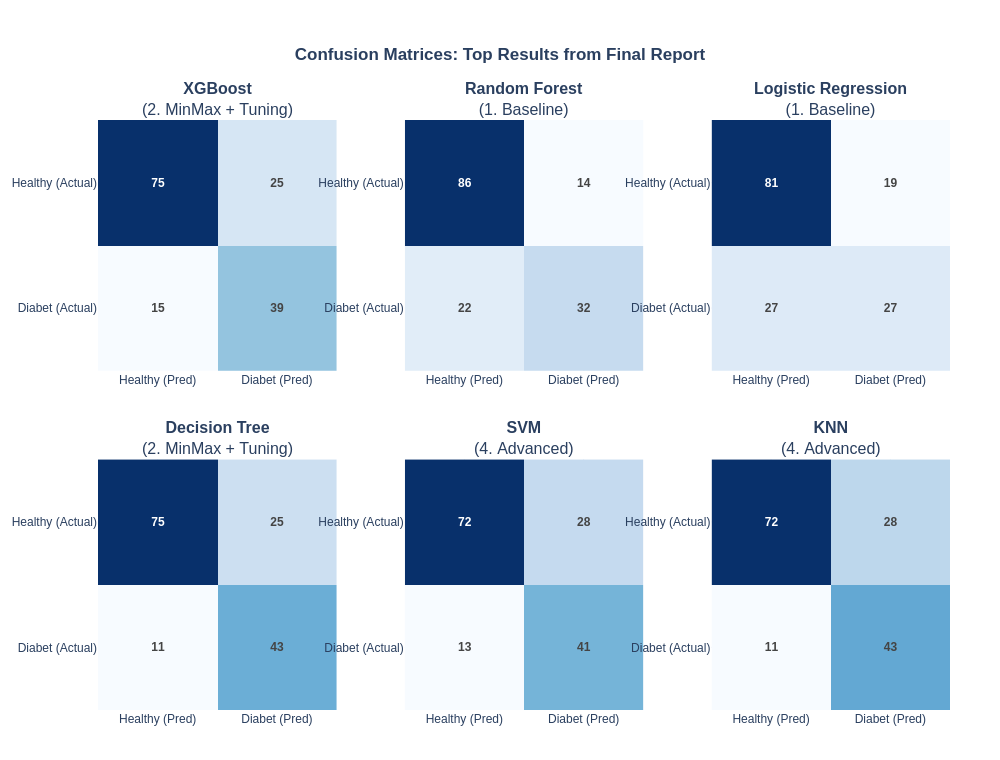

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.metrics import confusion_matrix

pio.renderers.default = "png"

def get_corrected_df_for_report(df_source, stage_name, prep_name_for_fixed_stage=None):
    temp_df = df_source.copy()
    temp_df['Stage'] = stage_name
    if stage_name == '4. Advanced':
        if 'Preprocessing' not in temp_df.columns:
            temp_df['Preprocessing'] = 'Unknown'
    else:
        temp_df['Preprocessing'] = prep_name_for_fixed_stage
    rename_dict = {
        'F1 Score': 'F1',
        'ROC AUC': 'ROC_AUC'
    }
    temp_df = temp_df.rename(columns=rename_dict)
    target_cols = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC', 'Stage', 'Preprocessing']
    available_cols = [c for c in target_cols if c in temp_df.columns]
    return temp_df[available_cols]

df1_fixed = get_corrected_df_for_report(results_df, '1. Baseline', 'None')
df2_fixed = get_corrected_df_for_report(final_df_min_max, '2. MinMax + Tuning', 'MinMax')
df3_fixed = get_corrected_df_for_report(final_df_std, '3. Standard + Tuning', 'Standard')
df4_fixed = get_corrected_df_for_report(full_report, '4. Advanced')

combined_report = pd.concat([df1_fixed, df2_fixed, df3_fixed, df4_fixed], ignore_index=True)

best_results_idx = combined_report.groupby('Model')['ROC_AUC'].idxmax()
top_models_info = combined_report.loc[best_results_idx].sort_values(by='ROC_AUC', ascending=False)

def get_best_pipeline(model_name, stage):
    if '1. Baseline' in stage:
        return baseline_models[model_name]
    elif '2. MinMax' in stage:
        return best_models_minmax[model_name]
    elif '3. Standard' in stage:
        return best_models_std[model_name]
    else:
        adv_rows = combined_report[
            (combined_report['Model'] == model_name) &
            (combined_report['Stage'] == '4. Advanced')
        ]
        best_prep = adv_rows.sort_values('ROC_AUC', ascending=False).iloc[0]['Preprocessing']
        return best_models_advanced[(best_prep, model_name)]

models_to_plot = top_models_info['Model'].tolist()
cols = 3
rows = (len(models_to_plot) + cols - 1) // cols

fig_cm = make_subplots(
    rows=rows, cols=cols,
    subplot_titles=[
        f"<b>{row['Model']}</b><br>({row['Stage']})"
        for _, row in top_models_info.iterrows()
    ],
    horizontal_spacing=0.08,
    vertical_spacing=0.15
)

for i, (_, row) in enumerate(top_models_info.iterrows()):
    model_name = row['Model']
    stage = row['Stage']

    pipe = get_best_pipeline(model_name, stage)

    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

    curr_row = (i // cols) + 1
    curr_col = (i % cols) + 1

    heatmap = go.Heatmap(
        z=cm,
        x=['Healthy (Pred)', 'Diabet (Pred)'],
        y=['Healthy (Actual)', 'Diabet (Actual)'],
        colorscale='Blues',
        showscale=False,
        text=cm,
        texttemplate="<b>%{text}</b>",
        hoverinfo="z"
    )

    fig_cm.add_trace(heatmap, row=curr_row, col=curr_col)

fig_cm.update_layout(
    title_text='<b>Confusion Matrices: Top Results from Final Report</b>',
    title_x=0.5,
    height=380 * rows,
    width=1000,
    margin=dict(l=50, r=50, t=120, b=50),
    template='plotly_white'
)

fig_cm.update_xaxes(tickangle=0)
fig_cm.update_yaxes(autorange='reversed')

fig_cm.show()
fig_cm.write_image("confusion_matrix.png")

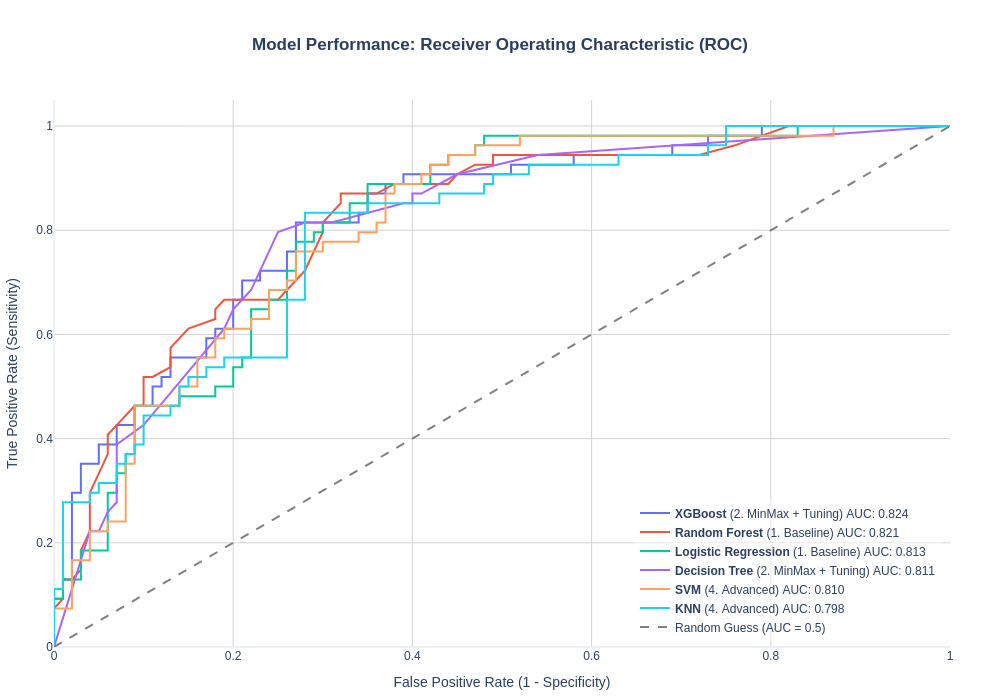

In [ ]:
import plotly.graph_objects as go
from sklearn.metrics import roc_curve, auc

pio.renderers.default = "png"

best_results_idx=combined_report.groupby('Model')['ROC_AUC'].idxmax()
top_models_info=combined_report.loc[best_results_idx].sort_values(by='ROC_AUC', ascending=False)

fig_roc=go.Figure()

for _, row in top_models_info.iterrows():
    model_name=row['Model']
    stage_info=row['Stage']
    pipe=get_best_pipeline(model_name, stage_info)

    if hasattr(pipe, "predict_proba"):
        y_prob=pipe.predict_proba(X_test)[:, 1]
    else:
        y_prob=pipe.decision_function(X_test)

    fpr, tpr, _=roc_curve(y_test, y_prob)
    roc_auc_val=auc(fpr, tpr)

    fig_roc.add_trace(go.Scatter(
        x=fpr, y=tpr,
        mode='lines',
        name=f"<b>{model_name}</b> ({stage_info}) AUC: {roc_auc_val:.3f}",
        hovertemplate = f"<b>{model_name}</b><br>FPR: %{{x:.3f}}<br>TPR: %{{y:.3f}}<extra></extra>"
    ))

fig_roc.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode='lines',
    line=dict(dash='dash', color='grey'),
    name='Random Guess (AUC = 0.5)'
))

fig_roc.update_layout(
    title='<b>Model Performance: Receiver Operating Characteristic (ROC)</b>',
    title_x=0.5,
    xaxis_title='False Positive Rate (1 - Specificity)',
    yaxis_title='True Positive Rate (Sensitivity)',
    xaxis=dict(range=[0, 1], gridcolor='lightgrey'),
    yaxis=dict(range=[0, 1.05], gridcolor='lightgrey'),
    width=1000,
    height=700,
    template='plotly_white',
    legend=dict(
        yanchor="bottom",
        y=0.01,
        xanchor="right",
        x=0.99,
        bgcolor="rgba(255, 255, 255, 0.5)"
    ),
    margin=dict(l=50, r=50, t=100, b=50)
)

fig_roc.show()
fig_roc.write_image("roc_models.png")

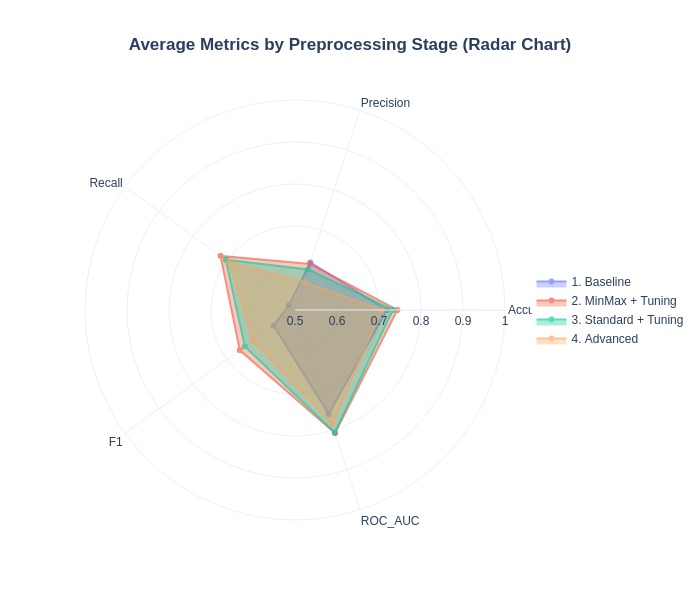

In [ ]:
import plotly.graph_objects as go

pio.renderers.default="png"

metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']

stage_avg = combined_report.groupby('Stage')[metrics].mean().reset_index()

fig_radar = go.Figure()
colors_radar = ['#636EFA', '#EF553B', '#00CC96', '#FFA15A']

for i, row in stage_avg.iterrows():
    vals = [row[m] for m in metrics]
    vals += [vals[0]]
    fig_radar.add_trace(go.Scatterpolar(
        r=vals,
        theta=metrics + [metrics[0]],
        fill='toself',
        name=row['Stage'],
        opacity=0.65,
        line_color=colors_radar[i % len(colors_radar)]
    ))

fig_radar.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0.5, 1.0])),
    title='<b>Average Metrics by Preprocessing Stage (Radar Chart)</b>',
    title_x=0.5,
    template='plotly_white',
    width=700, height=600,
    legend=dict(x=1.05, y=0.5)
)
fig_radar.show()


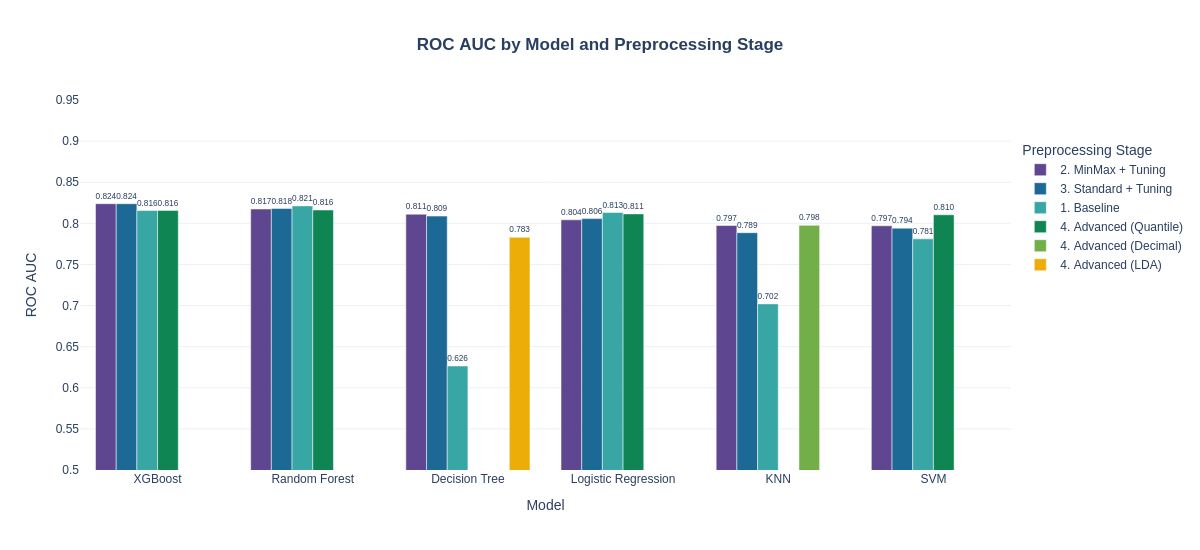

In [ ]:
df_plot = combined_report.sort_values('ROC_AUC', ascending=False).drop_duplicates(['Model', 'Stage']).copy()

pio.renderers.default="png"

df_plot['Stage_Full'] = df_plot.apply(
    lambda x: f"{x['Stage']} ({x['Preprocessing']})" if 'Advanced' in x['Stage'] else x['Stage'],
    axis=1
)

fig_auc = px.bar(
    df_plot,
    x='Model',
    y='ROC_AUC',
    color='Stage_Full',
    barmode='group',
    title='<b>ROC AUC by Model and Preprocessing Stage</b>',
    color_discrete_sequence=px.colors.qualitative.Prism,
    text_auto='.3f'
)

fig_auc.update_traces(textposition='outside', textfont_size=9)
fig_auc.update_layout(
    title_x=0.5, template='plotly_white',
    xaxis_title='Model', yaxis_title='ROC AUC',
    yaxis=dict(range=[0.5, 0.95]),
    width=1200, height=550,
    legend=dict(title='Preprocessing Stage', x=1.01, y=0.9)
)
fig_auc.show()
fig_auc.write_image("roc_auc_model.png")

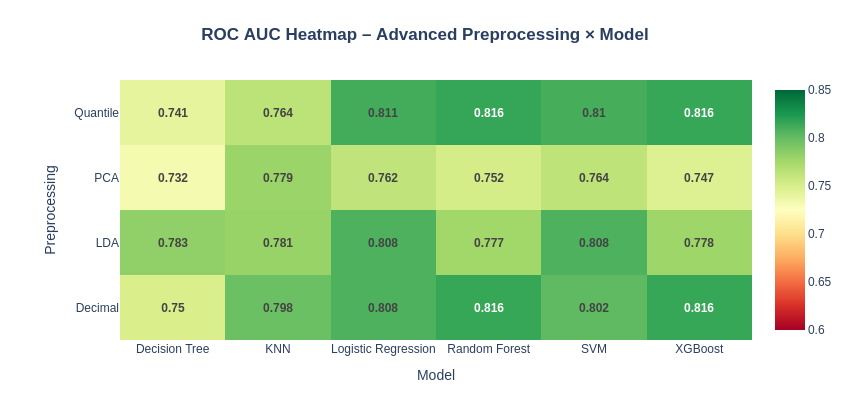

In [ ]:
import plotly.graph_objects as go

pio.renderers.default="png"

adv = combined_report[combined_report['Stage'] == '4. Advanced'].copy()

hm_data = adv.pivot_table(index='Preprocessing', columns='Model', values='ROC_AUC')

fig_hm = go.Figure(go.Heatmap(
    z=hm_data.values,
    x=hm_data.columns.tolist(),
    y=hm_data.index.tolist(),
    colorscale='RdYlGn',
    zmin=0.60, zmax=0.85,
    text=hm_data.values.round(3),
    texttemplate='<b>%{text}</b>',
    hovertemplate='Preprocessing: %{y}<br>Model: %{x}<br>ROC AUC: %{z:.3f}<extra></extra>'
))
fig_hm.update_layout(
    title='<b>ROC AUC Heatmap – Advanced Preprocessing × Model</b>',
    title_x=0.5, template='plotly_white',
    xaxis_title='Model', yaxis_title='Preprocessing',
    width=850, height=420,
    margin=dict(l=120, r=50, t=80, b=80)
)
fig_hm.show()
fig_hm.write_image("advanced_heatmap.png")


## 6. Dimensionality Reduction – PCA Scree Plot

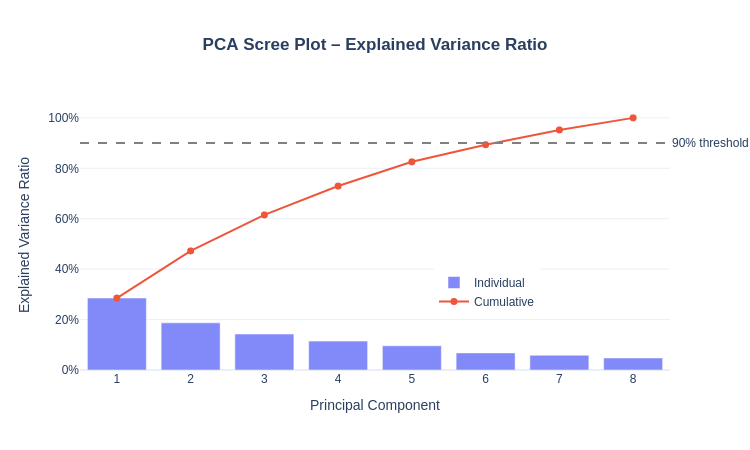

In [ ]:
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

pio.renderers.default="png"

X_pca = df.drop('Outcome', axis=1).copy()

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_pca)

X_scaled = StandardScaler().fit_transform(X_imputed)
pca_full = PCA().fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = explained.cumsum()
n_components = range(1, len(explained) + 1)

fig_scree = go.Figure()
fig_scree.add_trace(go.Bar(
    x=list(n_components), y=explained,
    name='Individual', marker_color='#636EFA', opacity=0.8
))
fig_scree.add_trace(go.Scatter(
    x=list(n_components), y=cumulative,
    name='Cumulative', mode='lines+markers',
    line=dict(color='#EF553B', width=2),
    marker=dict(size=7)
))
fig_scree.add_hline(y=0.90, line_dash='dash', line_color='grey',
                    annotation_text='90% threshold', annotation_position='right')
fig_scree.update_layout(
    title='<b>PCA Scree Plot – Explained Variance Ratio</b>',
    title_x=0.5, template='plotly_white',
    xaxis=dict(title='Principal Component', tickvals=list(n_components)),
    yaxis=dict(title='Explained Variance Ratio', tickformat='.0%'),
    width=750, height=450,
    legend=dict(x=0.6, y=0.2)
)
fig_scree.show()

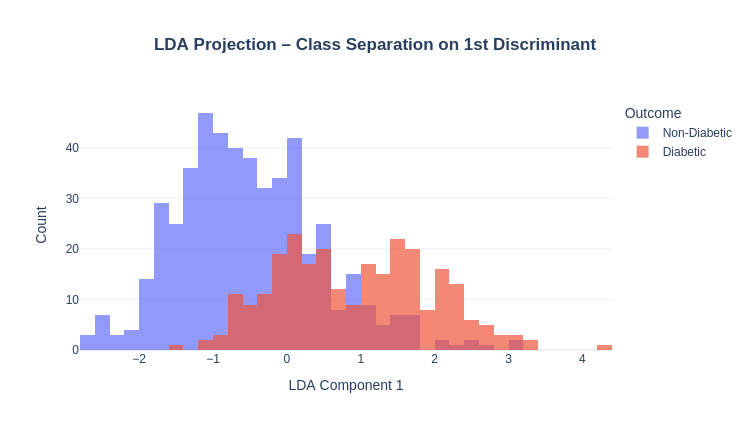

In [ ]:
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.impute import SimpleImputer

pio.renderers.default="png"

X_lda_raw = df.drop('Outcome', axis=1).copy()

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_lda_raw)

X_sc  = StandardScaler().fit_transform(X_imputed)
y_lbl = df['Outcome'].values

lda = LinearDiscriminantAnalysis()
X_lda = lda.fit_transform(X_sc, y_lbl).flatten()

fig_lda = go.Figure()
for cls, label, col in zip([0, 1], ['Non-Diabetic', 'Diabetic'], ['#636EFA', '#EF553B']):
    fig_lda.add_trace(go.Histogram(
        x=X_lda[y_lbl == cls],
        name=label, opacity=0.7,
        marker_color=col, nbinsx=30
    ))
fig_lda.update_layout(
    barmode='overlay',
    title='<b>LDA Projection – Class Separation on 1st Discriminant</b>',
    title_x=0.5, template='plotly_white',
    xaxis_title='LDA Component 1',
    yaxis_title='Count',
    width=750, height=430,
    legend=dict(title='Outcome')
)
fig_lda.show()

## 7. Feature Importance (Random Forest)

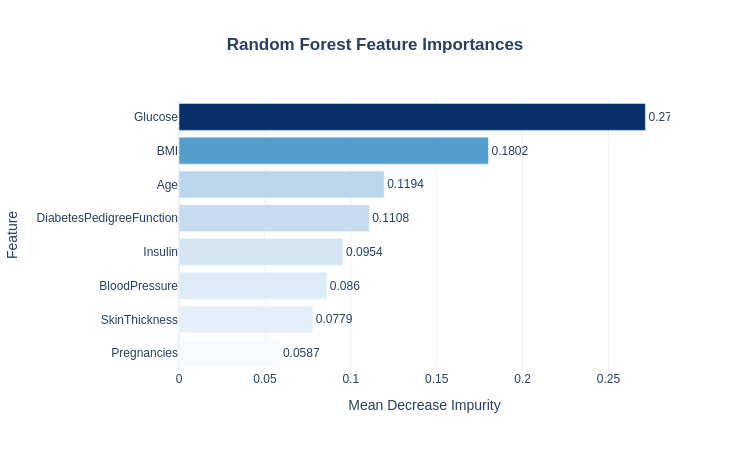

In [ ]:
import plotly.express as px

pio.renderers.default="png"

rf_pipe = best_models_minmax.get('Random Forest') or best_models_std.get('Random Forest')
rf_model = rf_pipe.named_steps['clf']

feature_names = df.drop('Outcome', axis=1).columns.tolist()
importances = rf_model.feature_importances_

fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=True)

fig_fi = px.bar(fi_df, x='Importance', y='Feature',
                orientation='h',
                color='Importance',
                color_continuous_scale='Blues',
                title='<b>Random Forest Feature Importances</b>',
                text=fi_df['Importance'].round(4))
fig_fi.update_traces(textposition='outside')
fig_fi.update_layout(
    title_x=0.5, template='plotly_white',
    xaxis_title='Mean Decrease Impurity', yaxis_title='Feature',
    coloraxis_showscale=False,
    width=750, height=450,
    margin=dict(l=130, r=80)
)
fig_fi.show()

### Logistic Regression Feature Importances (Coefficients)

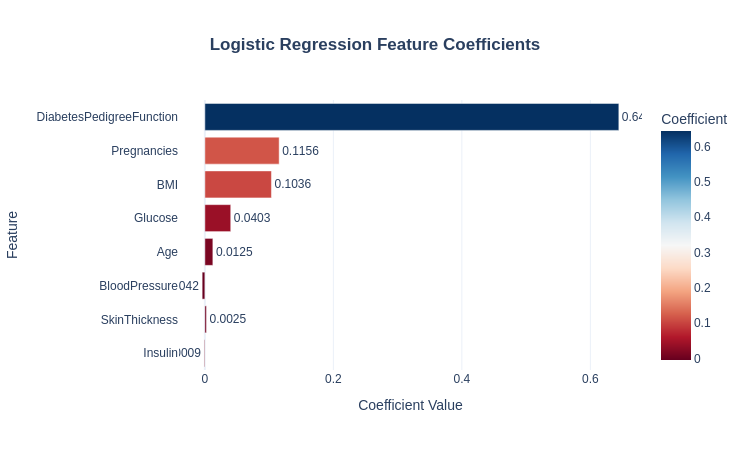

In [ ]:
import plotly.express as px

pio.renderers.default="png"

logreg_best_row = combined_report[(combined_report['Model'] == 'Logistic Regression')].sort_values('ROC_AUC', ascending=False).iloc[0]
logreg_pipe = get_best_pipeline(logreg_best_row['Model'], logreg_best_row['Stage'])

from sklearn.pipeline import Pipeline

if isinstance(logreg_pipe, Pipeline):
    logreg_model = logreg_pipe.named_steps['clf']
else:
    logreg_model = logreg_pipe

if hasattr(logreg_model, 'coef_'):
    feature_names = df.drop('Outcome', axis=1).columns.tolist()
    coefficients = logreg_model.coef_[0]

    fi_df_lr = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
    fi_df_lr['Abs_Coefficient'] = np.abs(fi_df_lr['Coefficient'])
    fi_df_lr = fi_df_lr.sort_values('Abs_Coefficient', ascending=True)

    fig_fi_lr = px.bar(fi_df_lr, x='Coefficient', y='Feature',
                       orientation='h',
                       color='Coefficient',
                       color_continuous_scale=px.colors.sequential.RdBu,
                       title='<b>Logistic Regression Feature Coefficients</b>',
                       text=fi_df_lr['Coefficient'].round(4))
    fig_fi_lr.update_traces(textposition='outside')
    fig_fi_lr.update_layout(
        title_x=0.5, template='plotly_white',
        xaxis_title='Coefficient Value', yaxis_title='Feature',
        coloraxis_showscale=True,
        width=750, height=450,
        margin=dict(l=130, r=80)
    )
    fig_fi_lr.show()
else:
    print("Logistic Regression model does not have 'coef_' attribute.")

### Decision Tree Feature Importances

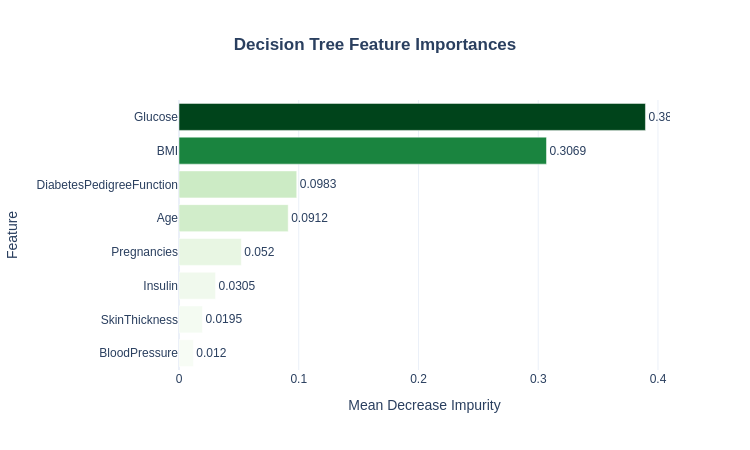

In [ ]:
import plotly.express as px

pio.renderers.default="png"

dtree_best_row = combined_report[(combined_report['Model'] == 'Decision Tree')].sort_values('ROC_AUC', ascending=False).iloc[0]
dtree_pipe = get_best_pipeline(dtree_best_row['Model'], dtree_best_row['Stage'])

dtree_model = dtree_pipe.named_steps['clf']

if hasattr(dtree_model, 'feature_importances_'):
    feature_names = df.drop('Outcome', axis=1).columns.tolist()
    importances = dtree_model.feature_importances_

    fi_df_dt = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    fi_df_dt = fi_df_dt.sort_values('Importance', ascending=True)

    fig_fi_dt = px.bar(fi_df_dt, x='Importance', y='Feature',
                       orientation='h',
                       color='Importance',
                       color_continuous_scale='Greens',
                       title='<b>Decision Tree Feature Importances</b>',
                       text=fi_df_dt['Importance'].round(4))
    fig_fi_dt.update_traces(textposition='outside')
    fig_fi_dt.update_layout(
        title_x=0.5, template='plotly_white',
        xaxis_title='Mean Decrease Impurity', yaxis_title='Feature',
        coloraxis_showscale=False,
        width=750, height=450,
        margin=dict(l=130, r=80)
    )
    fig_fi_dt.show()
else:
    print("Decision Tree model does not have 'feature_importances_' attribute.")

### XGBoost Feature Importances

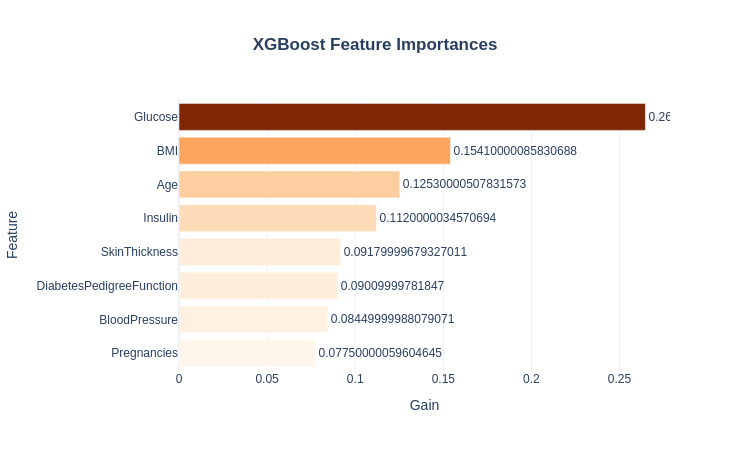

In [ ]:
import plotly.express as px

pio.renderers.default="png"

xgb_best_row = combined_report[(combined_report['Model'] == 'XGBoost')].sort_values('ROC_AUC', ascending=False).iloc[0]
xgb_pipe = get_best_pipeline(xgb_best_row['Model'], xgb_best_row['Stage'])

xgb_model = xgb_pipe.named_steps['clf']

if hasattr(xgb_model, 'feature_importances_'):
    feature_names = df.drop('Outcome', axis=1).columns.tolist()
    importances = xgb_model.feature_importances_

    fi_df_xgb = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    fi_df_xgb = fi_df_xgb.sort_values('Importance', ascending=True)

    fig_fi_xgb = px.bar(fi_df_xgb, x='Importance', y='Feature',
                        orientation='h',
                        color='Importance',
                        color_continuous_scale='Oranges',
                        title='<b>XGBoost Feature Importances</b>',
                        text=fi_df_xgb['Importance'].round(4))
    fig_fi_xgb.update_traces(textposition='outside')
    fig_fi_xgb.update_layout(
        title_x=0.5, template='plotly_white',
        xaxis_title='Gain', yaxis_title='Feature',
        coloraxis_showscale=False,
        width=750, height=450,
        margin=dict(l=130, r=80)
    )
    fig_fi_xgb.show()
else:
    print("XGBoost model does not have 'feature_importances_' attribute.")

## 8. Precision–Recall Curves

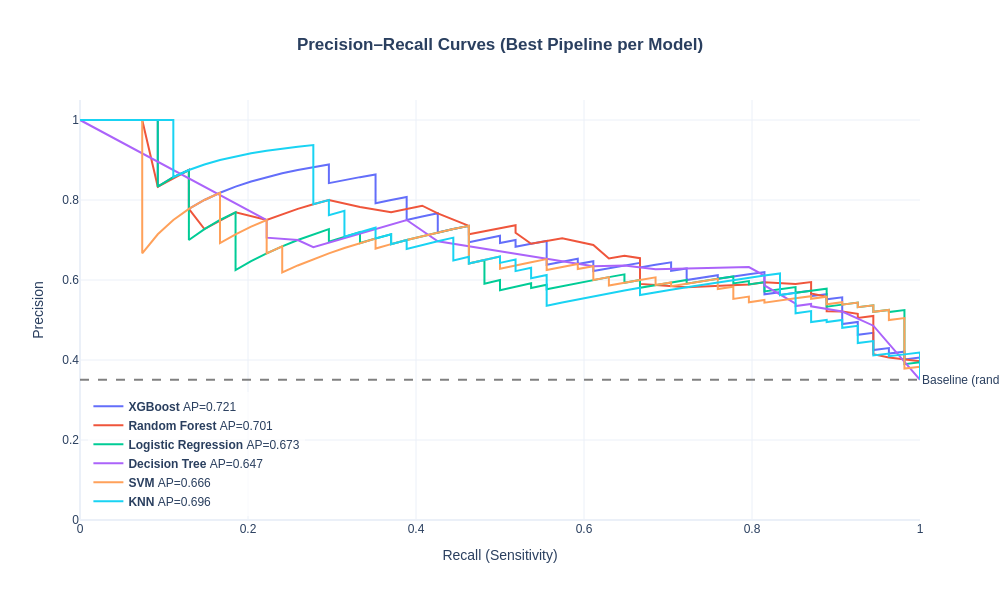

In [ ]:
import plotly.graph_objects as go
from sklearn.metrics import precision_recall_curve, average_precision_score

pio.renderers.default="png"

fig_pr = go.Figure()

for _, row in top_models_info.iterrows():
    model_name = row['Model']
    stage_info  = row['Stage']
    pipe = get_best_pipeline(model_name, stage_info)

    if hasattr(pipe, 'predict_proba'):
        y_prob = pipe.predict_proba(X_test)[:, 1]
    else:
        y_prob = pipe.decision_function(X_test)

    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)

    fig_pr.add_trace(go.Scatter(
        x=recall_vals, y=precision_vals,
        mode='lines',
        name=f'<b>{model_name}</b> AP={ap:.3f}',
        hovertemplate=f'<b>{model_name}</b><br>Recall: %{{x:.3f}}<br>Precision: %{{y:.3f}}<extra></extra>'
    ))

fig_pr.add_hline(y=y_test.mean(), line_dash='dash', line_color='grey',
                 annotation_text='Baseline (random)', annotation_position='right')

fig_pr.update_layout(
    title='<b>Precision–Recall Curves (Best Pipeline per Model)</b>',
    title_x=0.5,
    xaxis_title='Recall (Sensitivity)',
    yaxis_title='Precision',
    xaxis=dict(range=[0, 1]),
    yaxis=dict(range=[0, 1.05]),
    template='plotly_white',
    width=1000, height=600,
    legend=dict(x=0.01, y=0.01, bgcolor='rgba(255,255,255,0.7)')
)
fig_pr.show()


## 9. Summary – Best Result per Model

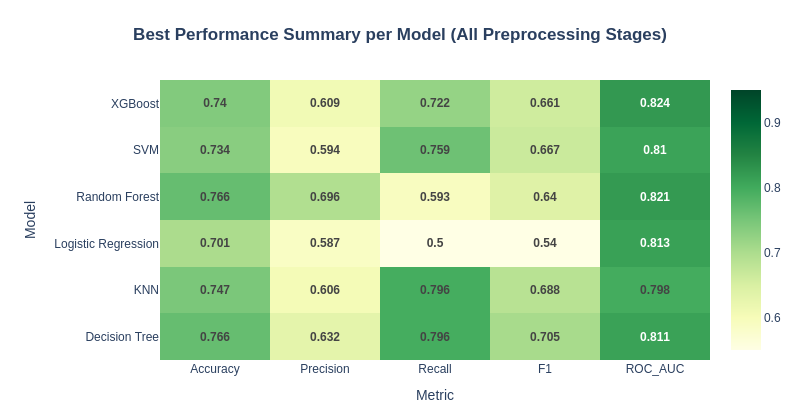

In [ ]:
import plotly.graph_objects as go

pio.renderers.default="png"

metrics_sel = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']
best_per_model = combined_report.loc[combined_report.groupby('Model')['ROC_AUC'].idxmax()]
best_per_model = best_per_model.set_index('Model')[metrics_sel]

fig_sum = go.Figure(go.Heatmap(
    z=best_per_model.values,
    x=metrics_sel,
    y=best_per_model.index.tolist(),
    colorscale='YlGn',
    zmin=0.55, zmax=0.95,
    text=best_per_model.values.round(3),
    texttemplate='<b>%{text}</b>',
    hovertemplate='Model: %{y}<br>Metric: %{x}<br>Value: %{z:.3f}<extra></extra>'
))
fig_sum.update_layout(
    title='<b>Best Performance Summary per Model (All Preprocessing Stages)</b>',
    title_x=0.5, template='plotly_white',
    xaxis_title='Metric', yaxis_title='Model',
    width=800, height=420,
    margin=dict(l=160, r=50, t=80, b=60)
)
fig_sum.show()
fig_sum.write_image("best_models.png")
